Using device: cpu
Epoch [1/10], Loss: 204.3828
Epoch [2/10], Loss: 180.5512
Epoch [3/10], Loss: 177.2150
Epoch [4/10], Loss: 175.4414
Epoch [5/10], Loss: 174.3254
Epoch [6/10], Loss: 173.3397
Epoch [7/10], Loss: 172.5143
Epoch [8/10], Loss: 171.8032
Epoch [9/10], Loss: 171.0924
Epoch [10/10], Loss: 170.5389
Latent representation shape: (10000, 2)


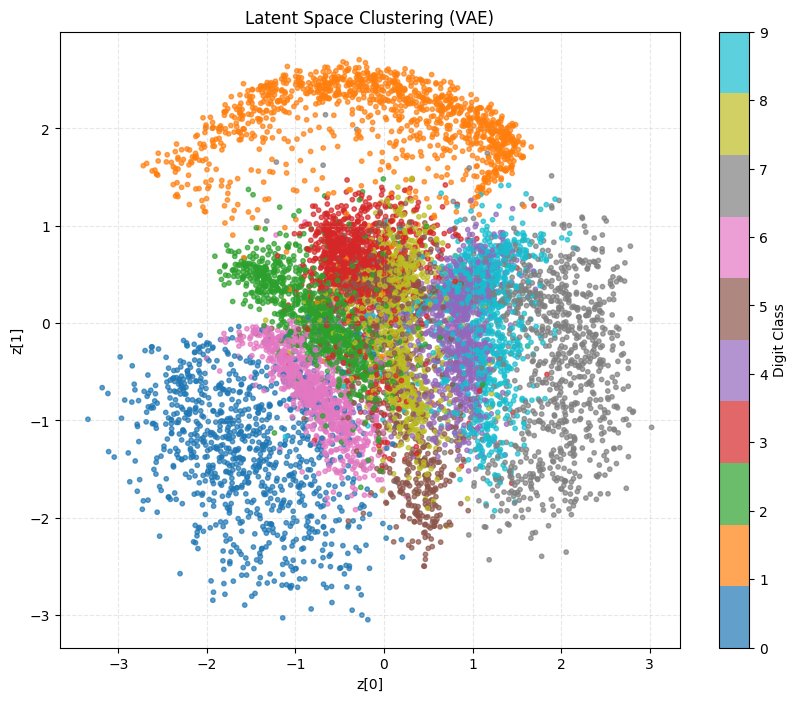

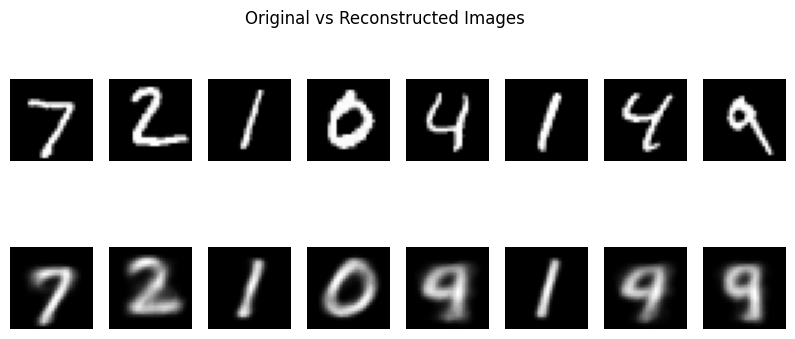

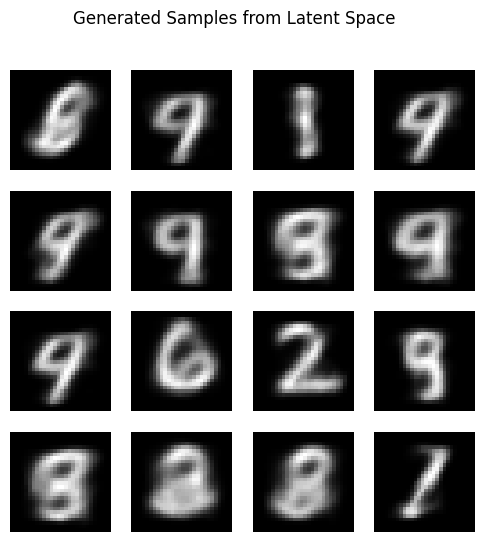

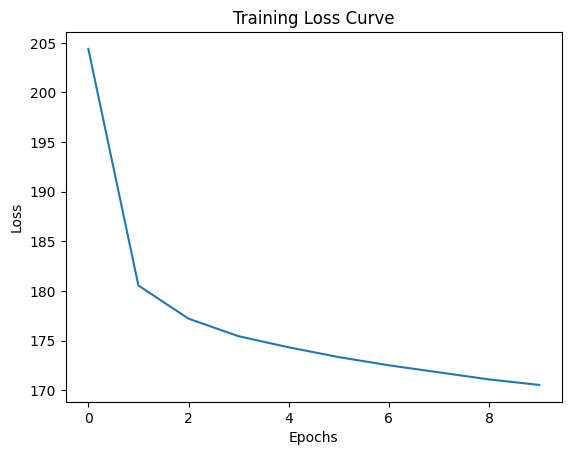

In [11]:
# =========================
# VAE + LATENT SPACE CLUSTERING (FULL CODE)
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# DATASET PREPARATION (MNIST)
# =========================
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# =========================
# VAE MODEL DEFINITION
# =========================
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=2):  # latent_dim = 2 for visualization
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.relu(self.fc2(z))
        return self.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# =========================
# LOSS FUNCTION (β-VAE)
# =========================
def loss_function(recon_x, x, mu, logvar, beta=4):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD

# =========================
# TRAINING THE VAE
# =========================
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for data, _ in train_loader:
        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# =========================
# LATENT SPACE EXTRACTION
# =========================
model.eval()

latent_points = []
labels_list = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.view(-1, 784).to(device)

        mu, logvar = model.encode(data)

        # Use mu instead of sampled z for clearer clusters
        z = mu

        latent_points.append(z.cpu())
        labels_list.append(labels)

latent_points = torch.cat(latent_points, dim=0).numpy()
labels_list = torch.cat(labels_list, dim=0).numpy()

print("Latent representation shape:", latent_points.shape)

# =========================
# LATENT SPACE CLUSTERING PLOT
# =========================
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    latent_points[:, 0],
    latent_points[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.colorbar(scatter, label="Digit Class")
plt.title("Latent Space Clustering (VAE)")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# =========================
# RECONSTRUCTION VISUALIZATION
# =========================
data, _ = next(iter(test_loader))
data = data.view(-1, 784).to(device)

with torch.no_grad():
    recon, _, _ = model(data)

n = 8
plt.figure(figsize=(10, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(data[i].cpu().view(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(recon[i].cpu().view(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Original vs Reconstructed Images")
plt.show()

# =========================
# GENERATED SAMPLES
# =========================
with torch.no_grad():
    z = torch.randn(16, 2).to(device)
    samples = model.decode(z).cpu().view(-1, 1, 28, 28)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Generated Samples from Latent Space")
plt.show()

# =========================
# LOSS CURVE
# =========================
plt.plot(train_losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()